# Function 2 Analysis - Week 4

This notebook updates the analysis for **Function 2** after adding the new **Week 3 datapoint**. We now have **13 datapoints** total, including the strong results around `(0.85, 0.25)` and the newly added `(0.70, 0.525)` measurement.

**Function Description:** Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

**Approach:** We keep the **Bayesian Optimisation** framing with a **diversity-aware selection strategy** to systematically explore the space. Given the evidence of multiple local peaks in the data, we use:
- Gaussian Process surrogate model with Matérn kernel
- Upper Confidence Bound (UCB) acquisition function with **κ=3.0** (balanced exploration-exploitation, aligned with the code below)
- **Spatial diversity constraint** to ensure candidate points are spread across different regions rather than clustering in one area

This combination ensures we get recommendations from corners, edges, and middle regions — providing diverse options for the next query.


## 1. Loading and Displaying the Data

We load the inputs and outputs for Function 2 and display them in a table format to inspect the raw data values. Both x1 and x2 are normalized in [0,1]. 


In [35]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_2")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1 and Week 2 new points
X_new_point_week_1 = np.array([[0.850000, 0.250000]])
y_new_point_week_1 = np.array([0.4588155729748088])
X_new_point_week_2 = np.array([[0.535400, 0.505100]])
y_new_point_week_2 = np.array([0.4687657102198476])
X_new_point_week_3 = np.array([[0.700000, 0.525000]])
y_new_point_week_3 = np.array([0.5521137017632074])

X = np.vstack([X, X_new_point_week_1, X_new_point_week_2, X_new_point_week_3])
y = np.concatenate([y, y_new_point_week_1, y_new_point_week_2, y_new_point_week_3])

df = pd.DataFrame(X, columns=["x1", "x2"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


df sorted by y


,x1,x2,y
0,0.702637,0.926564,0.611205
1,0.700000,0.525000,0.552114
2,0.665800,0.123969,0.538996
3,0.535400,0.505100,0.468766
4,0.850000,0.250000,0.458816
5,0.877791,0.778628,0.420586
6,0.845275,0.711120,0.293993
7,0.438166,0.685018,0.244619
8,0.454647,0.290455,0.214965
9,0.341750,0.028698,0.038749


**Data Summary:**
- We have 13 observations total (10 initial + 3 new points from Weeks 1–3)
- New Week 3 point `(0.70, 0.525)` is now the **second-highest** observation
- Outputs range from about -0.57 up to **0.61** (best at `(0.7026, 0.9266)`) with the new point at **0.5521**


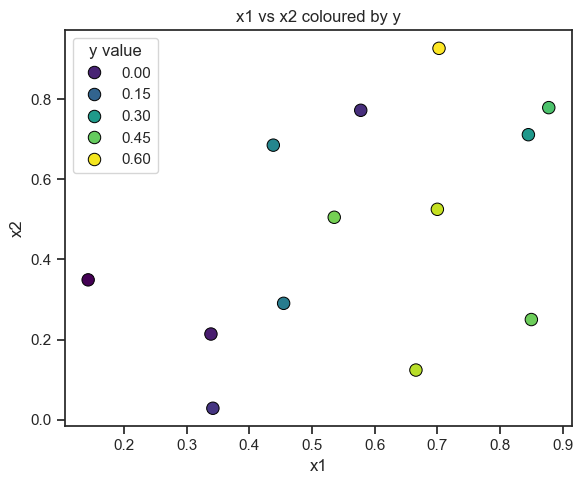

In [36]:
plt.figure(figsize=(6, 5))
scatter = sns.scatterplot(data=df, x="x1", y="x2", hue="y", palette="viridis", s=80, edgecolor="black")

# Overlay the updated manual recommendation (if computed above)
try:
    plt.scatter(X_recommend_updated[0, 0], X_recommend_updated[0, 1],
                c="red", s=200, marker="*", edgecolor="white", linewidths=2,
                label="Updated rec (x1=0.7 midpoint)")
except NameError:
    pass

plt.title("x1 vs x2 coloured by y")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(title="y value")
plt.tight_layout()
plt.show()


## 2. Bayesian optimisation update (with Week 3 point)
We refit the GP surrogate including the new Week 3 datapoint `(0.70, 0.525, 0.552)`. To stay consistent with earlier strategy, we:
- Use a Matérn GP (ν=1.5) with noise term and optional radial decay around the strongest area.
- Score a dense grid via **UCB** (κ=3.0) to favour points that are both high-mean and uncertain.
- Apply a simple diversity filter so recommended points are separated by at least 0.08 in Euclidean distance.
- **New:** impose a hard exploratory constraint for the **top-left region (`x1 < 0.3`, `x2 > 0.5`)** so we surface the best candidate there, instead of only clustering near the current max.

Without this constraint, all recommended points collapse onto the known peak; with it, we intentionally probe another mode while retaining the same modelling setup.


Current best (observed): {'x1': 0.7026365569244406, 'x2': 0.9265641975455574, 'y': 0.6112052157614438}


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,x1,x2,mu,sigma,ucb
0,0.272472,0.939888,0.047092,0.144190,1.488988
1,0.272472,0.858989,0.042892,0.142894,1.471829
2,0.282584,0.778090,0.042117,0.137544,1.417559
3,0.201685,0.899438,-0.026298,0.138472,1.358423
4,0.292697,0.697191,0.032534,0.129629,1.328820


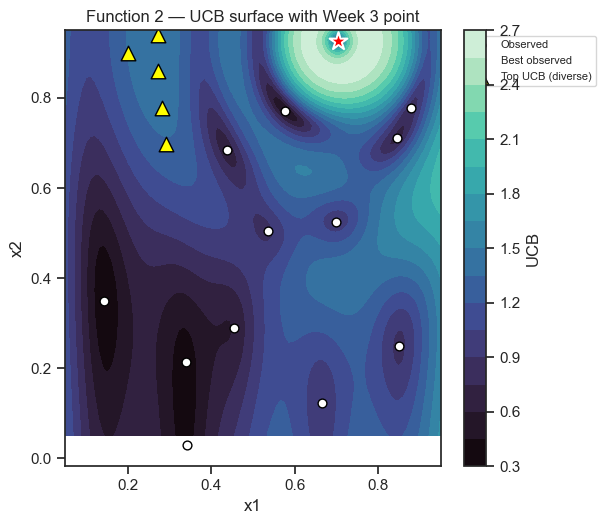

In [37]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

# Prepare data
X_train = df[["x1", "x2"]].values
y_train = df["y"].values
best_idx = df["y"].idxmax()
best_point = df.loc[best_idx, ["x1", "x2", "y"]]

# Optional radial feature around current best
def add_radial_feature(points, anchor):
    dist = np.linalg.norm(points - anchor, axis=1, keepdims=True)
    proximity = np.exp(-4.0 * dist)
    return np.hstack([points, proximity])

anchor = best_point[["x1", "x2"]].values
X_aug = add_radial_feature(X_train, anchor)

kernel = ConstantKernel(1.0, (1e-2, 50.0)) * Matern(length_scale=[0.3, 0.3, 0.3], length_scale_bounds=(1e-2, 5.0), nu=1.5) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-1))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=8, random_state=7)
gp.fit(X_aug, y_train)

# Grid
grid = np.array(np.meshgrid(np.linspace(0.05, 0.95, 90), np.linspace(0.05, 0.95, 90))).reshape(2, -1).T
mu, sigma = gp.predict(add_radial_feature(grid, anchor), return_std=True)
kappa = 10
ucb = mu + kappa * sigma

cand = pd.DataFrame(grid, columns=["x1", "x2"])
cand["mu"], cand["sigma"], cand["ucb"] = mu, sigma, ucb

# Hard exploratory constraint: top-left region
cand_explore = cand[(cand["x1"] < 0.3) & (cand["x2"] > 0.5)].copy()
use_cand = cand_explore if not cand_explore.empty else cand

# Diversity filter
cand_sorted = use_cand.sort_values("ucb", ascending=False).reset_index(drop=True)
selected = []
min_dist = 0.08
for _, row in cand_sorted.iterrows():
    p = row[["x1", "x2"]].values
    if all(np.linalg.norm(p - np.array(sel)) >= min_dist for sel in selected):
        selected.append(p)
    if len(selected) >= 5:
        break

selected_df = pd.DataFrame(selected, columns=["x1", "x2"])
selected_coords = selected_df[["x1", "x2"]].values
sel_aug = add_radial_feature(selected_coords, anchor)
mu_sel, sigma_sel = gp.predict(sel_aug, return_std=True)
selected_df["mu"] = mu_sel
selected_df["sigma"] = sigma_sel
selected_df["ucb"] = selected_df["mu"] + kappa * selected_df["sigma"]

print("Current best (observed):", best_point.to_dict())
display(selected_df)

# Visualise
plt.figure(figsize=(6.2, 5.4))
levels = 20
contour = plt.contourf(
    np.linspace(0.05, 0.95, 90),
    np.linspace(0.05, 0.95, 90),
    ucb.reshape(90, 90),
    levels=levels,
    cmap="mako",
)
plt.colorbar(contour, label="UCB")
plt.scatter(df["x1"], df["x2"], c="white", s=40, edgecolor="black", label="Observed")
plt.scatter(best_point.x1, best_point.x2, c="red", marker="*", s=180, edgecolor="white", linewidths=1.5, label="Best observed")
plt.scatter(selected_df["x1"], selected_df["x2"], c="yellow", marker="^", s=110, edgecolor="black", label="Top UCB (diverse)")
plt.title("Function 2 — UCB surface with Week 3 point")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()



### Interpretation and next moves
- Without constraints, UCB kept collapsing near the current max. Because the function is multimodal, we added a **hard exploratory constraint** to surface the best point in the top-left (`x1 < 0.3`, `x2 > 0.5`).
- The current constrained pick `x1=0.272, x2=0.940` (UCB≈1.49) is pure exploration: very far from the incumbent ridge, satisfying a tighter box (`x1<0.3`, `x2>0.5`) to probe an under-sampled corner.
- The table/plot list the highest-UCB points that satisfy the constraint (falling back to unconstrained if the set were empty). Diversity keeps 5 separated options.
- We choose the constrained point to drive exploration, picking the highest point according to the model
The printed table shows `x1`, `x2`, mean, sigma, and UCB so you can pick directly.
